# TabPFN for Marketing Mix Modeling
## Comparison Model to Bayesian MMM (PyMC-Marketing)

This notebook implements a TabPFN-based Marketing Mix Model as a direct comparison to the Bayesian MMM.
The structure mirrors the Bayesian MMM notebook to enable direct comparison of results.

**Research Question:**
Can a pretrained foundation model (TabPFN) match or outperform a carefully specified
Bayesian MMM without any domain-specific prior knowledge?

**Models compared:**
| Model | Adstock | Saturation | Training |
|-------|---------|------------|----------|
| Bayesian MMM | Learned via MCMC | Learned via MCMC | ~minutes |
| TabPFN (no adstock) | ✗ | ✗ | ~3 seconds |
| TabPFN (with adstock) | Manual preprocessing | ✗ | ~3 seconds |
| TabPFN (adstock + saturation) | Manual preprocessing | Manual preprocessing | ~3 seconds |

## 1. Setup & Installation

We install two packages:
- `tabpfn-client`: the official PriorLabs package for TabPFN — runs inference on PriorLabs servers
- `pyreadr`: needed to read the Robyn `.RData` dataset format

In [1]:
!pip install tabpfn-client pyreadr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.1/254.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


### Authentication

TabPFN requires a one-time login to PriorLabs (ux.priorlabs.ai).
When prompted, select option [2] to log in with your existing account.

In [2]:
import tabpfn_client
tabpfn_client.init()

from tabpfn_client import TabPFNRegressor
print("TabPFN Client ready!")

########  ########   ###  #########  #########       ###         #####     ########  ########
     ###        ##   ###  ###   ###        ###       ###        ###  ###   ##   ###  ###     
########  #######    ###  ###   ###  #######         ###        ########   ######    ########
###       ###   ##   ###  ###   ###  ###   ###       ###        ###  ###   ##   ###       ###
###       ###   ##   ###  #########  ###   ###       ########   ###  ###   ########  ########                      

Thanks for being part of the journey

TabPFN is under active development, please help us improve and report any bugs/ideas you find.

Report issues: https://github.com/priorlabs/tabpfn-client/issues

Press Ctrl+C anytime to exit

...

Email:

seb.leipold@web.de
Password: ··········


Output()

Login successful!

TabPFN Client ready!


In [3]:
# Core libraries
import requests
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MaxAbsScaler, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Data Loading

The same Robyn simulated weekly dataset used in the Bayesian MMM is loaded here.
Using the identical dataset ensures that any performance differences between models
are attributable to modeling choices rather than data differences.

The dataset contains 208 weekly observations with:
- **Target variable:** `revenue` — weekly revenue to be predicted
- **Media channels:** TV, OOH, Print, Facebook, Search spend
- **Control variables:** competitor sales, newsletter subscribers

In [4]:
# Download Robyn simulated dataset from GitHub
# Identical source as Bayesian MMM notebook
url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"

response = requests.get(url)

with open("dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

# Read RData file
result = pyreadr.read_r("dt_simulated_weekly.RData")
df = result["dt_simulated_weekly"]

# Convert date column and sort chronologically
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Variable definitions — identical to Bayesian MMM notebook
target = "revenue"

media_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_S",
    "search_S"
]

control_cols = [
    "competitor_sales_B",
    "newsletter"
]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (208, 12)
Columns: ['DATE', 'revenue', 'tv_S', 'ooh_S', 'print_S', 'facebook_I', 'search_clicks_P', 'search_S', 'competitor_sales_B', 'facebook_S', 'events', 'newsletter']


,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,events,newsletter
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,2.430128e+07,0.000000,0.000000,8125009,7607.132915,na,19401.653846
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,5.527033e+06,9837.238486,4133.333333,7901549,1141.952450,na,14791.000000
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,na,14544.000000
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,1.054977e+07,12268.070319,4253.333333,8122883,2800.490677,na,2800.000000
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,2.934090e+06,9467.248023,3613.333333,7105985,689.582605,na,15478.000000


## 3. Train-Test Split

A chronological 80/20 split is applied — identical to the Bayesian MMM.

**Why chronological?**
Marketing data is time-series data. A random split would allow the model to learn
from future observations during training, which would artificially inflate performance.
A chronological split reflects realistic forecasting conditions where future data is unknown.

- **Training set:** first 166 weeks (used to fit the model)
- **Test set:** last 42 weeks (used to evaluate out-of-sample performance)

Total observations: 208
Train observations: 166
Test observations: 42


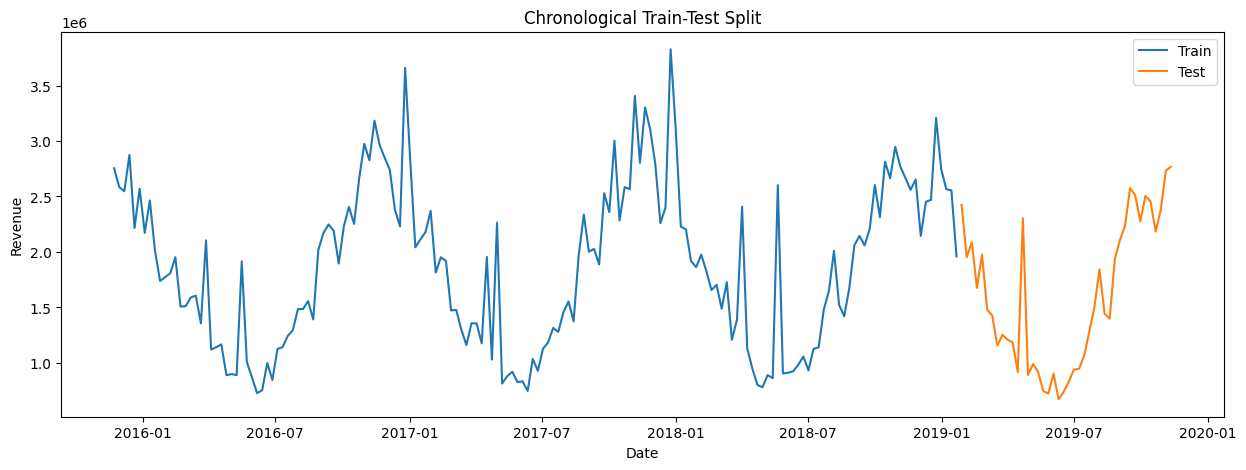

In [5]:
# Chronological train-test split (80/20)
# Identical to Bayesian MMM
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print("Total observations:", len(df))
print("Train observations:", len(train_df))
print("Test observations:",  len(test_df))

# Visualize split
plt.figure(figsize=(15, 5))
plt.plot(train_df["DATE"], train_df[target], label="Train")
plt.plot(test_df["DATE"],  test_df[target],  label="Test")
plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

## 4. Transformation Functions

Two marketing-specific transformations are defined here and used across all model variants.

### Geometric Adstock
Advertising effects do not only impact revenue in the week they are aired —
they persist across multiple weeks with decreasing intensity.
The geometric adstock transformation models this carryover effect:
each week's spend is a weighted sum of current and past spend values,
where the weights decay geometrically according to the alpha parameter.

**In the Bayesian MMM:** alpha is learned as a posterior distribution via MCMC.
**In TabPFN:** we use the posterior mean alpha values from the Bayesian MMM as fixed preprocessing parameters.

### Logistic Saturation
Advertising exhibits diminishing returns — the first euro spent is more effective
than the thousandth. The logistic saturation transformation compresses high spend values
to capture this nonlinear relationship.

**In the Bayesian MMM:** saturation is learned jointly with all other parameters.
**In TabPFN:** we apply it as a fixed preprocessing step using the Bayesian MMM posterior beta values.
Note: TabPFN may implicitly learn saturation-like patterns from data even without this transformation.

In [6]:
def geometric_adstock(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    """
    Geometric adstock transformation.

    Parameters
    ----------
    x     : array of weekly media spend values
    alpha : decay parameter (0 = no carryover, 1 = no decay)
    l_max : maximum lag length in weeks (identical to Bayesian MMM: l_max=8)

    Returns
    -------
    x_adstocked : array of adstock-transformed spend values
    """
    x_adstocked = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        for l in range(l_max):
            if t - l >= 0:
                x_adstocked[t] += (alpha ** l) * x[t - l]
    return x_adstocked


def logistic_saturation(x: np.ndarray, beta: float) -> np.ndarray:
    """
    Logistic saturation transformation.

    Parameters
    ----------
    x    : array of (adstock-transformed, normalized) media spend values
    beta : saturation parameter from Bayesian MMM posterior
           higher beta = faster saturation = stronger diminishing returns

    Returns
    -------
    saturated values in range (0, 1)
    """
    return 1 / (1 + np.exp(-beta * x))


# Adstock alpha values from Bayesian MMM posterior means
adstock_alphas = {
    "tv_S":       0.241,
    "ooh_S":      0.572,
    "print_S":    0.428,
    "facebook_S": 0.540,
    "search_S":   0.558,
}

# Saturation beta values from Bayesian MMM posterior means
saturation_betas = {
    "tv_S":       0.258,
    "ooh_S":      0.162,
    "print_S":    0.132,
    "facebook_S": 0.185,
    "search_S":   0.093,
}

print("Transformation functions defined.")
print("Adstock alphas:", adstock_alphas)
print("Saturation betas:", saturation_betas)

Transformation functions defined.
Adstock alphas: {'tv_S': 0.241, 'ooh_S': 0.572, 'print_S': 0.428, 'facebook_S': 0.54, 'search_S': 0.558}
Saturation betas: {'tv_S': 0.258, 'ooh_S': 0.162, 'print_S': 0.132, 'facebook_S': 0.185, 'search_S': 0.093}


## 5. Scaling

TabPFN — like the Bayesian MMM — benefits from normalized input features.
We apply the same scaling pipeline as in the Bayesian MMM notebook:

- **Media channels:** MaxAbsScaler — scales values to [-1, 1] range while preserving sparsity
- **Control variables:** StandardScaler — zero mean, unit variance
- **Target variable:** kept on original scale for interpretable metric computation

**Important:** The scaler is always fitted on training data only and then applied to test data.
This prevents information leakage from the test set.

In [7]:
def scale_features(train_df, test_df, media_cols, control_cols, target, epsilon=1e-6):
    """
    Apply MaxAbsScaler to media columns and StandardScaler to control columns.
    Scaler is fitted on training data only to prevent data leakage.

    Returns scaled train/test dataframes and numpy feature arrays.
    """
    train = train_df.copy()
    test  = test_df.copy()

    # Add epsilon to avoid exact zeros
    train[media_cols] = train[media_cols] + epsilon
    test[media_cols]  = test[media_cols]  + epsilon

    # Media: MaxAbsScaler
    media_scaler = MaxAbsScaler()
    train[media_cols] = media_scaler.fit_transform(train[media_cols])
    test[media_cols]  = media_scaler.transform(test[media_cols])

    # Controls: StandardScaler
    control_scaler = StandardScaler()
    train[control_cols] = control_scaler.fit_transform(train[control_cols])
    test[control_cols]  = control_scaler.transform(test[control_cols])

    feature_cols = media_cols + control_cols

    X_train = train[feature_cols].values
    X_test  = test[feature_cols].values
    y_train = train[target].values
    y_test  = test[target].values

    return X_train, X_test, y_train, y_test


feature_cols = media_cols + control_cols
print("Scaling function defined.")
print("Feature columns:", feature_cols)

Scaling function defined.
Feature columns: ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S', 'competitor_sales_B', 'newsletter']


## 6. Channel Contribution & ROAS Helper

Since TabPFN does not provide built-in channel contribution estimates
(unlike the Bayesian MMM which outputs posterior distributions for each channel),
we estimate contributions via **permutation importance**:

1. Generate baseline predictions with all channels present
2. Set one channel to zero (counterfactual: as if that channel had zero spend)
3. The difference in total predicted revenue = that channel's contribution

ROAS is then computed as:
```
ROAS = channel_contribution / total_original_spend
```

**Note:** Contributions are computed on the **training period** to match the Bayesian MMM methodology,
which also reports channel contributions over the training period.

In [8]:
def estimate_contributions_and_roas(regressor, X_train, media_cols, feature_cols, train_df):
    """
    Estimate channel contributions via permutation importance on training data.
    Compute ROAS using original (unscaled) training spend.

    Parameters
    ----------
    regressor   : fitted TabPFN regressor
    X_train     : scaled training feature matrix
    media_cols  : list of media channel column names
    feature_cols: list of all feature column names
    train_df    : original (unscaled) training dataframe for spend calculation

    Returns
    -------
    contributions : pd.Series of total contribution per channel
    roas          : pd.Series of ROAS per channel
    """
    channel_contributions = {}

    for channel in media_cols:
        # Baseline: predict with all channels
        y_baseline = regressor.predict(X_train)

        # Counterfactual: set this channel to zero
        X_zeroed = X_train.copy()
        col_idx = feature_cols.index(channel)
        X_zeroed[:, col_idx] = 0

        y_counterfactual = regressor.predict(X_zeroed)

        # Contribution = total revenue difference
        contribution = (y_baseline - y_counterfactual).sum()
        channel_contributions[channel] = contribution

        print(f"  {channel}: {contribution:,.2f}")

    contributions = pd.Series(channel_contributions).sort_values(ascending=False)

    # ROAS: contribution / original training spend
    total_spend = train_df[media_cols].sum()
    roas = (contributions / total_spend).sort_values(ascending=False)

    return contributions, roas


print("Contribution and ROAS helper function defined.")

Contribution and ROAS helper function defined.


---
# Model 1: TabPFN WITHOUT Adstock (Baseline Ablation)

This is the purest form of TabPFN for MMM — no domain-specific preprocessing at all.
Raw media spend values are fed directly into the model.

This variant tests whether TabPFN can learn carryover and saturation effects
implicitly from the data without any explicit transformations.

**Limitation:** TabPFN treats each row as independent and has no built-in
mechanism to capture temporal dependencies across weeks.

In [9]:
# Prepare raw data (no adstock, no saturation)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = scale_features(
    train_df, test_df, media_cols, control_cols, target
)

print("Raw data ready (no adstock, no saturation).")
print("X_train shape:", X_train_raw.shape)
print("X_test shape:",  X_test_raw.shape)

Raw data ready (no adstock, no saturation).
X_train shape: (166, 7)
X_test shape: (42, 7)


In [10]:
# Fit TabPFN on raw data
# A single forward pass replaces hours of MCMC sampling
regressor_raw = TabPFNRegressor()
regressor_raw.fit(X_train_raw, y_train_raw)

print("TabPFN (no adstock) fitting complete!")

00:00 Fitting... -

00:01 Fitting... Done!
TabPFN (no adstock) fitting complete!


00:00 Predicting... \

00:01 Predicting... Done!


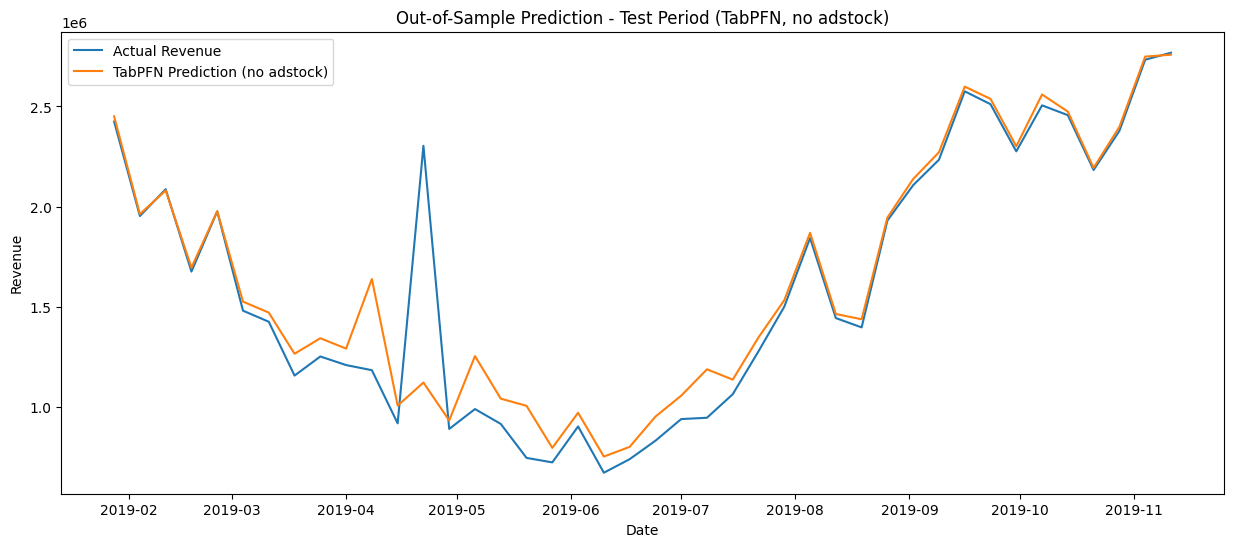

Forecast Accuracy Results (TabPFN, no adstock):
  MAE:  99,086.33
  RMSE: 214,200.44
  MAPE: 7.97%


In [11]:
# Out-of-sample prediction
y_pred_raw = regressor_raw.predict(X_test_raw)

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_df["DATE"], y_test_raw, label="Actual Revenue")
plt.plot(test_df["DATE"], y_pred_raw, label="TabPFN Prediction (no adstock)")
plt.title("Out-of-Sample Prediction - Test Period (TabPFN, no adstock)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

# Forecast accuracy metrics
mae_raw  = mean_absolute_error(y_test_raw, y_pred_raw)
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mape_raw = mean_absolute_percentage_error(y_test_raw, y_pred_raw) * 100

print("Forecast Accuracy Results (TabPFN, no adstock):")
print(f"  MAE:  {mae_raw:,.2f}")
print(f"  RMSE: {rmse_raw:,.2f}")
print(f"  MAPE: {mape_raw:.2f}%")

Estimating channel contributions (TabPFN, no adstock):
00:04 Predicting... -

00:05 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
  tv_S: 12,606,085.69
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
  ooh_S: 1,281,318.81
00:00 Predicting... -

...

00:01 Predicting... Done!
  print_S: 3,733,949.75
00:00 Predicting... -

00:11 Predicting... Done!
00:00 Predicting... -

00:04 Predicting... Done!
  facebook_S: 2,917,359.19
00:00 Predicting... -

00:01 Predicting... Done!
00:03 Predicting... \

00:04 Predicting... Done!
  search_S: 376,197.56


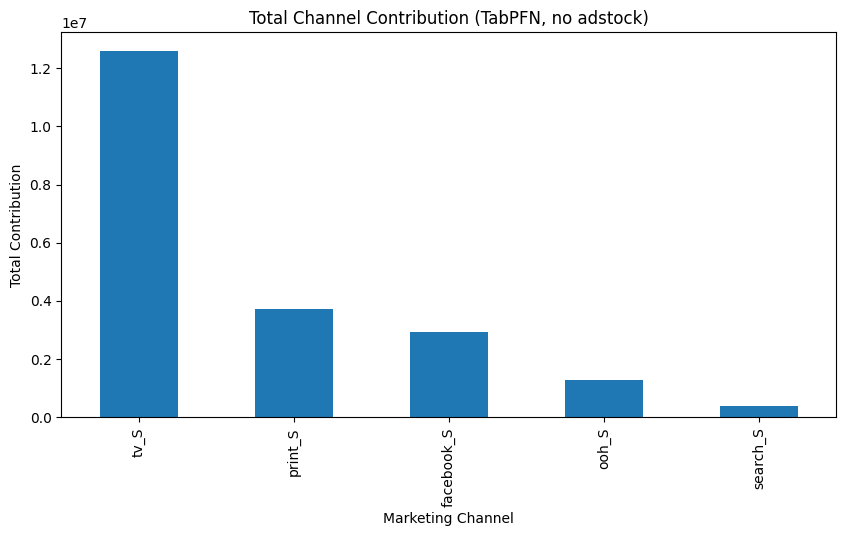


Estimated ROAS by Channel (TabPFN, no adstock):
facebook_S    8.098
print_S       5.582
tv_S          4.550
search_S      0.429
ooh_S         0.148
dtype: float64


In [12]:
# Channel contributions and ROAS (no adstock)
print("Estimating channel contributions (TabPFN, no adstock):")
contrib_raw, roas_raw = estimate_contributions_and_roas(
    regressor_raw, X_train_raw, media_cols, feature_cols, train_df
)

# Plot contributions
plt.figure(figsize=(10, 5))
contrib_raw.plot(kind="bar")
plt.title("Total Channel Contribution (TabPFN, no adstock)")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Contribution")
plt.show()

print("\nEstimated ROAS by Channel (TabPFN, no adstock):")
print(roas_raw.round(3))

---
# Model 2: TabPFN WITH Adstock

A geometric adstock transformation is applied as preprocessing before fitting TabPFN.
This gives the model access to temporal carryover information that it cannot learn on its own.

The adstock alpha values are taken from the Bayesian MMM posterior means:
- tv_S: 0.241 (fast decay)
- ooh_S: 0.572 (slow decay)
- print_S: 0.428
- facebook_S: 0.540
- search_S: 0.558

**Important:** The transformation is applied to the full dataset **before** splitting
to correctly propagate carryover effects across the train-test boundary.

In [13]:
# Apply geometric adstock to full dataset before splitting
df_adstocked = df.copy()

for col, alpha in adstock_alphas.items():
    df_adstocked[col] = geometric_adstock(df[col].values, alpha=alpha, l_max=8)

# Re-split with adstocked values
train_adstocked = df_adstocked.iloc[:split_idx].copy()
test_adstocked  = df_adstocked.iloc[split_idx:].copy()

print("Adstock transformation complete.")
print(train_adstocked[media_cols].describe().round(2))

Adstock transformation complete.
            tv_S      ooh_S   print_S  facebook_S  search_S
count     166.00     166.00    166.00      166.00    166.00
mean    21982.32  120506.85   7021.09     4656.18  11593.55
std     31827.39  109445.78   6863.46     3920.96   8214.20
min         0.00       0.00      0.00        0.00      0.00
25%      2245.77   43290.10   1925.94     1451.04   5318.62
50%      9793.55   83788.30   5280.09     3780.57   9011.31
75%     27037.97  172773.68  10120.20     7320.59  15760.85
max    158238.37  593949.12  35379.40    17193.67  36338.19


In [14]:
# Scale adstock-transformed data
X_train_ads, X_test_ads, y_train_ads, y_test_ads = scale_features(
    train_adstocked, test_adstocked, media_cols, control_cols, target
)

print("Adstock data scaled.")
print("X_train shape:", X_train_ads.shape)

Adstock data scaled.
X_train shape: (166, 7)


In [15]:
# Fit TabPFN with adstock
regressor_ads = TabPFNRegressor()
regressor_ads.fit(X_train_ads, y_train_ads)

print("TabPFN (with adstock) fitting complete!")

00:01 Fitting... -

00:01 Fitting... Done!
TabPFN (with adstock) fitting complete!


00:00 Predicting... -

00:01 Predicting... Done!


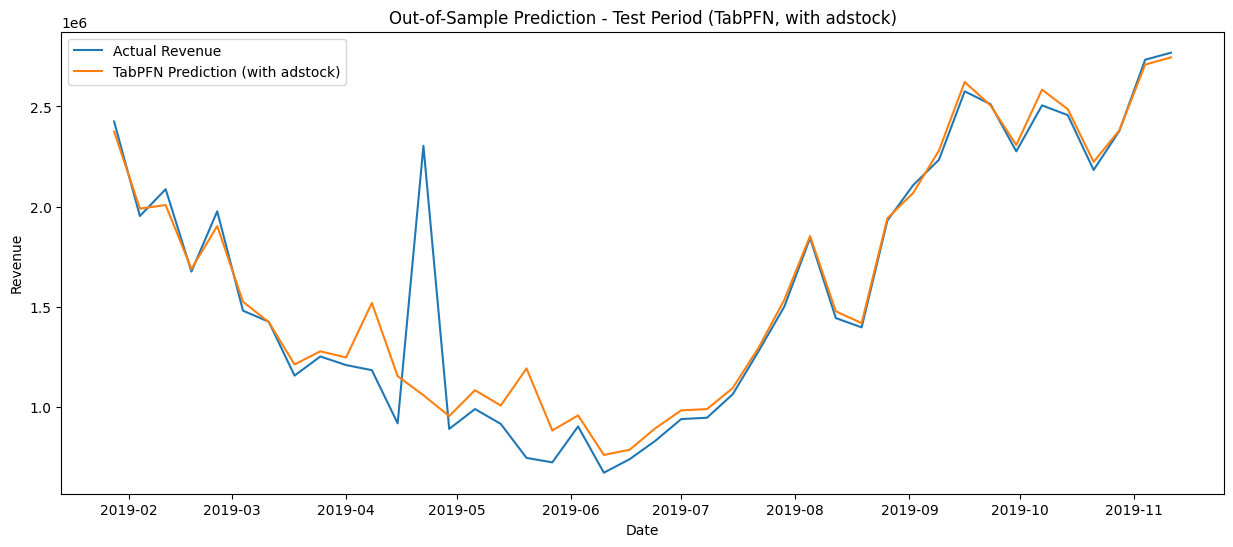

Forecast Accuracy Results (TabPFN, with adstock):
  MAE:  94,207.08
  RMSE: 219,723.31
  MAPE: 7.41%


In [16]:
# Out-of-sample prediction
y_pred_ads = regressor_ads.predict(X_test_ads)

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_df["DATE"], y_test_ads, label="Actual Revenue")
plt.plot(test_df["DATE"], y_pred_ads, label="TabPFN Prediction (with adstock)")
plt.title("Out-of-Sample Prediction - Test Period (TabPFN, with adstock)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

# Forecast accuracy metrics
mae_ads  = mean_absolute_error(y_test_ads, y_pred_ads)
rmse_ads = np.sqrt(mean_squared_error(y_test_ads, y_pred_ads))
mape_ads = mean_absolute_percentage_error(y_test_ads, y_pred_ads) * 100

print("Forecast Accuracy Results (TabPFN, with adstock):")
print(f"  MAE:  {mae_ads:,.2f}")
print(f"  RMSE: {rmse_ads:,.2f}")
print(f"  MAPE: {mape_ads:.2f}%")

Estimating channel contributions (TabPFN, with adstock):
00:00 Predicting... -

00:02 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
  tv_S: 15,665,870.00
00:01 Predicting... /

00:02 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
  ooh_S: 2,778,912.62
00:00 Predicting... -

...

00:01 Predicting... Done!
  print_S: 7,331,014.06
00:00 Predicting... \

00:01 Predicting... Done!
00:03 Predicting... \

00:04 Predicting... Done!
  facebook_S: 5,640,499.12
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
  search_S: 103,800.12


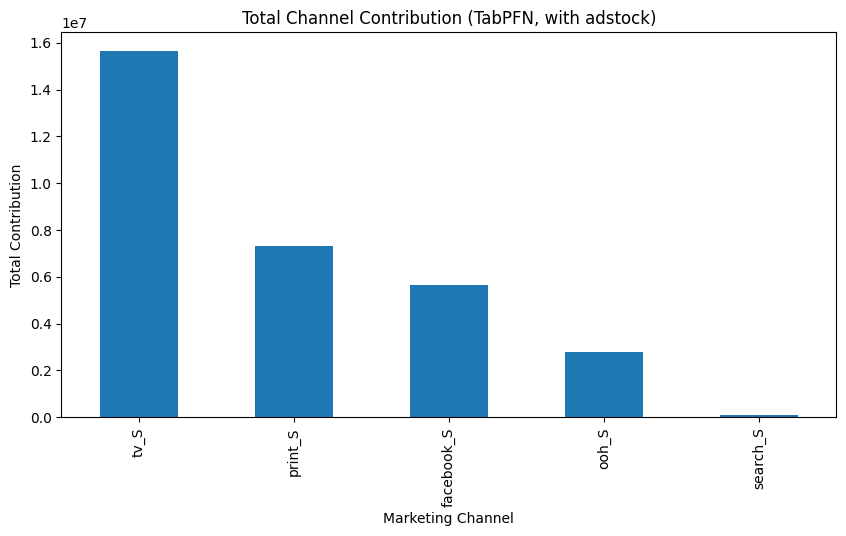


Estimated ROAS by Channel (TabPFN, with adstock):
facebook_S    15.657
print_S       10.959
tv_S           5.654
ooh_S          0.320
search_S       0.118
dtype: float64


In [17]:
# Channel contributions and ROAS (with adstock)
print("Estimating channel contributions (TabPFN, with adstock):")
contrib_ads, roas_ads = estimate_contributions_and_roas(
    regressor_ads, X_train_ads, media_cols, feature_cols, train_df
)

# Plot contributions
plt.figure(figsize=(10, 5))
contrib_ads.plot(kind="bar")
plt.title("Total Channel Contribution (TabPFN, with adstock)")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Contribution")
plt.show()

print("\nEstimated ROAS by Channel (TabPFN, with adstock):")
print(roas_ads.round(3))

---
# Model 3: TabPFN WITH Adstock AND Saturation

This variant adds a logistic saturation transformation on top of the adstock preprocessing.
The goal is to explicitly encode diminishing returns — the same structural assumption
that the Bayesian MMM makes through its Logistic Saturation prior.

**Implementation note:**
The saturation transformation must be applied to normalized values (0 to 1 range).
If applied to raw adstock values (which can be very large), all channels collapse
to the same saturation level and the transformation loses discriminative power.
Therefore we normalize each channel by its maximum value before applying saturation.

**Research question for this variant:**
Does explicitly encoding diminishing returns improve TabPFN, or does TabPFN
already learn saturation-like patterns implicitly from the data?

In [18]:
# Apply adstock + saturation to full dataset before splitting
df_adstock_sat = df.copy()

for col, alpha in adstock_alphas.items():
    # Step 1: Adstock transformation
    adstocked = geometric_adstock(df[col].values, alpha=alpha, l_max=8)

    # Step 2: Normalize to [0, 1] range before saturation
    # This prevents all channels from collapsing to the same saturation level
    adstocked_normalized = adstocked / (adstocked.max() + 1e-6)

    # Step 3: Logistic saturation transformation
    df_adstock_sat[col] = logistic_saturation(adstocked_normalized, beta=saturation_betas[col])

# Re-split
train_adstock_sat = df_adstock_sat.iloc[:split_idx].copy()
test_adstock_sat  = df_adstock_sat.iloc[split_idx:].copy()

print("Adstock + Saturation transformation complete.")
print("Values are now bounded between 0 and 1:")
print(train_adstock_sat[media_cols].describe().round(4))

Adstock + Saturation transformation complete.
Values are now bounded between 0 and 1:
           tv_S     ooh_S   print_S  facebook_S  search_S
count  166.0000  166.0000  166.0000    166.0000  166.0000
mean     0.5089    0.5082    0.5065      0.5125    0.5074
std      0.0129    0.0075    0.0064      0.0105    0.0053
min      0.5000    0.5000    0.5000      0.5000    0.5000
25%      0.5009    0.5030    0.5018      0.5039    0.5034
50%      0.5040    0.5057    0.5049      0.5102    0.5058
75%      0.5110    0.5118    0.5094      0.5197    0.5101
max      0.5641    0.5404    0.5330      0.5461    0.5232


In [19]:
# Scale adstock + saturation transformed data
X_train_sat, X_test_sat, y_train_sat, y_test_sat = scale_features(
    train_adstock_sat, test_adstock_sat, media_cols, control_cols, target
)

print("Adstock + saturation data scaled.")
print("X_train shape:", X_train_sat.shape)

Adstock + saturation data scaled.
X_train shape: (166, 7)


In [20]:
# Fit TabPFN with adstock + saturation
regressor_sat = TabPFNRegressor()
regressor_sat.fit(X_train_sat, y_train_sat)

print("TabPFN (adstock + saturation) fitting complete!")

00:00 Fitting... -

00:00 Fitting... Done!
TabPFN (adstock + saturation) fitting complete!


00:02 Predicting... \

00:03 Predicting... Done!


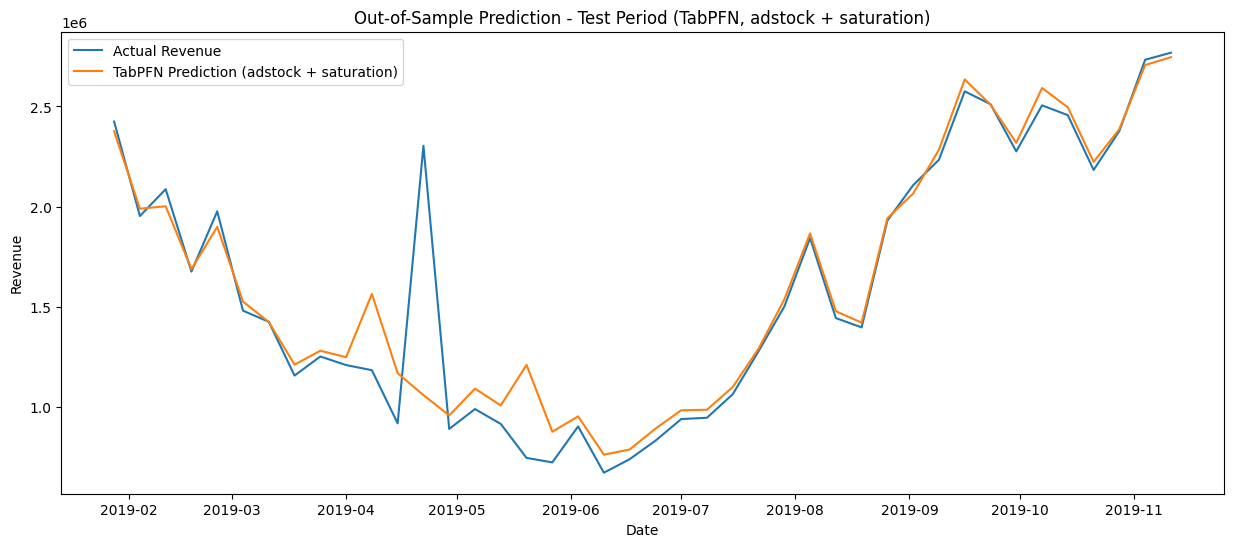

Forecast Accuracy Results (TabPFN, adstock + saturation):
  MAE:  97,901.44
  RMSE: 222,992.17
  MAPE: 7.68%


In [21]:
# Out-of-sample prediction
y_pred_sat = regressor_sat.predict(X_test_sat)

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_df["DATE"], y_test_sat, label="Actual Revenue")
plt.plot(test_df["DATE"], y_pred_sat, label="TabPFN Prediction (adstock + saturation)")
plt.title("Out-of-Sample Prediction - Test Period (TabPFN, adstock + saturation)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

# Forecast accuracy metrics
mae_sat  = mean_absolute_error(y_test_sat, y_pred_sat)
rmse_sat = np.sqrt(mean_squared_error(y_test_sat, y_pred_sat))
mape_sat = mean_absolute_percentage_error(y_test_sat, y_pred_sat) * 100

print("Forecast Accuracy Results (TabPFN, adstock + saturation):")
print(f"  MAE:  {mae_sat:,.2f}")
print(f"  RMSE: {rmse_sat:,.2f}")
print(f"  MAPE: {mape_sat:.2f}%")

Estimating channel contributions (TabPFN, adstock + saturation):
00:00 Predicting... -

00:05 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
  tv_S: 25,596,781.56
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
  ooh_S: 3,490,376.81
00:00 Predicting... \

...

00:01 Predicting... Done!
  print_S: 10,017,817.38
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
  facebook_S: 5,947,902.44
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
  search_S: -4,474,115.62


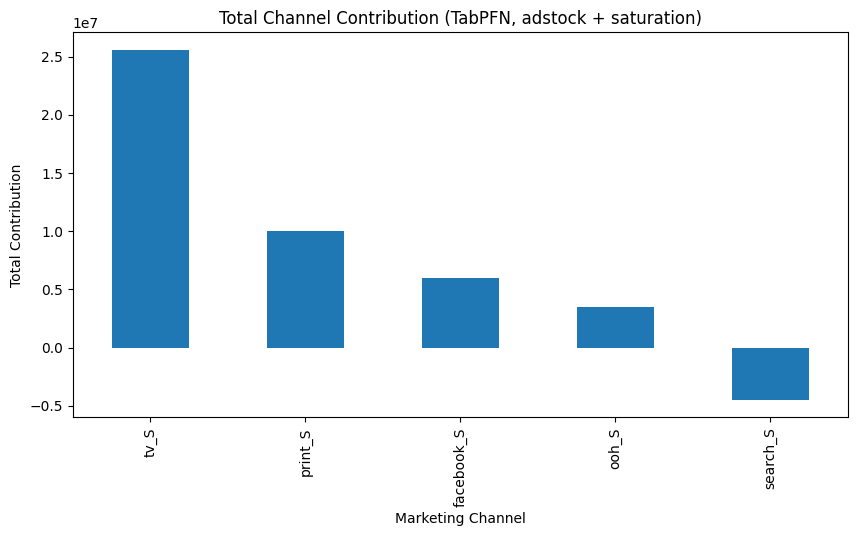


Estimated ROAS by Channel (TabPFN, adstock + saturation):
facebook_S    16.511
print_S       14.975
tv_S           9.239
ooh_S          0.402
search_S      -5.104
dtype: float64


In [22]:
# Channel contributions and ROAS (adstock + saturation)
print("Estimating channel contributions (TabPFN, adstock + saturation):")
contrib_sat, roas_sat = estimate_contributions_and_roas(
    regressor_sat, X_train_sat, media_cols, feature_cols, train_df
)

# Plot contributions
plt.figure(figsize=(10, 5))
contrib_sat.plot(kind="bar")
plt.title("Total Channel Contribution (TabPFN, adstock + saturation)")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Contribution")
plt.show()

print("\nEstimated ROAS by Channel (TabPFN, adstock + saturation):")
print(roas_sat.round(3))

---
# Final Comparison: All Models

All four models are compared across forecast accuracy metrics and ROAS estimates.

**Interpretation guidance:**
- **Forecast accuracy:** lower MAE, RMSE, MAPE = better predictive performance
- **ROAS:** higher = more revenue generated per euro of advertising spend
- **Channel ranking:** consistency across models indicates robust attribution

**Note on ROAS comparability:**
The Bayesian MMM ROAS values are based on normalized contributions (scaled units),
while TabPFN ROAS values are based on absolute revenue contributions.
The absolute magnitudes therefore differ, but the **channel rankings** are directly comparable.

In [23]:
# Forecast accuracy comparison — all models
metrics_comparison = pd.DataFrame({
    "Metric":                        ["MAE", "RMSE", "MAPE (%)"],
    "Bayesian MMM":                  [115134.78, 218368.30, 8.53],
    "TabPFN (no adstock)":           [mae_raw,  rmse_raw,  mape_raw],
    "TabPFN (adstock)":              [mae_ads,  rmse_ads,  mape_ads],
    "TabPFN (adstock + saturation)": [mae_sat,  rmse_sat,  mape_sat],
}).set_index("Metric").round(2)

print("Forecast Accuracy Comparison — All Models:")
print(metrics_comparison)

Forecast Accuracy Comparison — All Models:
          Bayesian MMM  TabPFN (no adstock)  TabPFN (adstock)  \
Metric                                                          
MAE          115134.78             99086.33          94207.08   
RMSE         218368.30            214200.44         219723.31   
MAPE (%)          8.53                 7.97              7.41   

          TabPFN (adstock + saturation)  
Metric                                   
MAE                            97901.44  
RMSE                          222992.17  
MAPE (%)                           7.68  


In [24]:
# ROAS comparison — all models (training period)
roas_comparison = pd.DataFrame({
    "Bayesian MMM": {
        "tv_S":       0.261,
        "facebook_S": 0.126,
        "ooh_S":      0.105,
        "print_S":    0.080,
        "search_S":   0.048,
    },
    "TabPFN (no adstock)":           roas_raw.to_dict(),
    "TabPFN (adstock)":              roas_ads.to_dict(),
    "TabPFN (adstock + saturation)": roas_sat.to_dict(),
}).round(3)

print("ROAS Comparison — All Models (training period):")
print(roas_comparison)

ROAS Comparison — All Models (training period):
            Bayesian MMM  TabPFN (no adstock)  TabPFN (adstock)  \
tv_S               0.261                4.550             5.654   
facebook_S         0.126                8.098            15.657   
ooh_S              0.105                0.148             0.320   
print_S            0.080                5.582            10.959   
search_S           0.048                0.429             0.118   

            TabPFN (adstock + saturation)  
tv_S                                9.239  
facebook_S                         16.511  
ooh_S                               0.402  
print_S                            14.975  
search_S                           -5.104  


In [25]:
# Channel ranking comparison
print("Channel Ranking by Contribution (training period):")
print(f"  Bayesian MMM:                  {['tv_S', 'facebook_S', 'search_S', 'ooh_S', 'print_S']}")
print(f"  TabPFN (no adstock):           {contrib_raw.index.tolist()}")
print(f"  TabPFN (adstock):              {contrib_ads.index.tolist()}")
print(f"  TabPFN (adstock + saturation): {contrib_sat.index.tolist()}")

Channel Ranking by Contribution (training period):
  Bayesian MMM:                  ['tv_S', 'facebook_S', 'search_S', 'ooh_S', 'print_S']
  TabPFN (no adstock):           ['tv_S', 'print_S', 'facebook_S', 'ooh_S', 'search_S']
  TabPFN (adstock):              ['tv_S', 'print_S', 'facebook_S', 'ooh_S', 'search_S']
  TabPFN (adstock + saturation): ['tv_S', 'print_S', 'facebook_S', 'ooh_S', 'search_S']
